# Real-asteroid evaluation (`test_real`)

Does v7 + the V2 RF post-processor, run as a **second stage on top of the LSST 5σ stack**, recover real fast-moving asteroids the stack misses — and at what false-positive cost on real difference images?

**Reproducible-from-zero.** Heavy steps (Butler build, GPU scoring, fine-tune) run on SLURM via the tracked runners in `ADCNN/scripts/test_real/` (see `REPRODUCE.md`); this notebook **documents the exact commands** and then loads the produced artifacts to render every table/plot. It runs CPU-only in the `asteroid_cnn` kernel — no GPU needed to view results.

Key caveat carried throughout: the real catalog is **selection-biased bright** (only *discovered* asteroids), so its raw recall is not a fair measure of the network — the faint-regime value is established on the synthetic sets (`Evaluation.ipynb`). `test_real`'s informative signals are **second-stage gain** (stack-missed recoveries) and **FP on real diffims**.

In [1]:
import os, sys, textwrap
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt

REPO = Path('.').resolve()
sys.path.insert(0, str(REPO))
DATA   = REPO / 'DATA_DIFFIM' / 'test_real'
RES    = REPO / 'experiments' / 'diffim_runs' / 'test_real' / 'results'
REALCSV = REPO / 'DATA' / 'sv_fast_movers_for_karlo_fast_with_pixels_rerun.csv'

def show(path, cmd=None, n=60):
    """Print an artifact if present, else the command that produces it."""
    p = Path(path)
    if p.exists():
        print(p.read_text()[: 8000] if p.suffix == '.txt' else f'[exists] {p}')
    else:
        print(f'[missing] {p}\n  produce with:\n    ' + (cmd or '(see REPRODUCE.md)'))

print('DATA :', DATA, '(exists)' if DATA.exists() else '(not built yet)')
print('RES  :', RES, '(exists)' if RES.exists() else '(no results yet)')

DATA : /sdf/data/rubin/user/mrakovci/Projects/Asteroid_detection_CNN/DATA_DIFFIM/test_real (exists)
RES  : /sdf/data/rubin/user/mrakovci/Projects/Asteroid_detection_CNN/experiments/diffim_runs/test_real/results (exists)


## §0 — Leakage check

No `(visit, detector)` of a real catalogued asteroid may have been used as a synthetic-injection background in any train/test set. The image unit is one CCD readout = `(visit, detector)`; train/test are synthetic injections so the real `ObjID`s never appear there as labels anyway. This cell recomputes the overlap directly (cheap, CPU).

In [2]:
real = pd.read_csv(REALCSV)
real_pairs = set(zip(real['FieldID'].astype('int64'), real['detector'].astype('int64')))
print(f'real catalog: {len(real)} sightings | {real.ObjID.nunique()} objects | '
      f'{len(real_pairs)} (visit,detector) pairs')
for f in ['DATA/train.csv','DATA/test.csv','DATA_DIFFIM/train.csv','DATA_DIFFIM/test.csv',
          'DATA_DIFFIM/test_5sigma/test.csv']:
    fp = REPO / f
    if not fp.exists():
        print(f'  {f:38s}  (absent)'); continue
    d = pd.read_csv(fp, usecols=['visit','detector'])
    pairs = set(zip(d['visit'].astype('int64'), d['detector'].astype('int64')))
    print(f'  {f:38s}  (visit,det) overlap with real = {len(pairs & real_pairs)}')
print('\n=> all zero  ==>  no leakage; Train/Test do NOT need recreating.')

real catalog: 2958 sightings | 340 objects | 2958 (visit,detector) pairs
  DATA/train.csv                          (visit,det) overlap with real = 0
  DATA/test.csv                           (visit,det) overlap with real = 0
  DATA_DIFFIM/train.csv                   (visit,det) overlap with real = 0
  DATA_DIFFIM/test.csv                    (visit,det) overlap with real = 0
  DATA_DIFFIM/test_5sigma/test.csv        (visit,det) overlap with real = 0

=> all zero  ==>  no leakage; Train/Test do NOT need recreating.


## §1 — Build the real-diffim test set

Non-injection build from genuine LSST difference images. Run on SLURM (LSST stack env):

```bash
sbatch ADCNN/scripts/test_real/slurm_build.sh scan  DATA/sv_fast_movers_for_karlo_fast_with_pixels_rerun.csv
sbatch ADCNN/scripts/test_real/slurm_build.sh build DATA/sv_fast_movers_for_karlo_fast_with_pixels_rerun.csv
```

Produces `DATA_DIFFIM/test_real/{test.h5,test.csv,panels.csv}` (byte-compatible with the synthetic `test_5sigma` sets). The catalog `x,y`/`angle` are stale w.r.t. the DP2 reprocessing — trails are reconstructed from the ephemeris RA/Dec + sky-rates through the PVI WCS (see `ADCNN/data/dataset_creation/build_test_real.py`).

In [3]:
if (DATA / 'panels.csv').exists():
    pan = pd.read_csv(DATA / 'panels.csv')
    cat = pd.read_csv(DATA / 'test.csv')
    print('panels :', pan.role.value_counts().to_dict(), '| total', len(pan))
    print(f'asteroid sightings: {len(cat)} | objects: {cat.ObjID.nunique()}')
    print(f'stack@5σ detects {int(cat.stack_detection.sum())}/{len(cat)} sightings '
          f'({100*cat.stack_detection.mean():.1f}%); '
          f'{cat.groupby("ObjID").stack_detection.any().sum()}/{cat.ObjID.nunique()} objects')
    if 'n_offccd' in pan: print('off-CCD reconstructions dropped:', int(pan.n_offccd.sum()))
else:
    print('[missing] DATA_DIFFIM/test_real — run the slurm_build.sh steps above.')

panels : {'asteroid': 2470, 'empty': 150} | total 2620
asteroid sightings: 2309 | objects: 292
stack@5σ detects 1356/2309 sightings (58.7%); 192/292 objects
off-CCD reconstructions dropped: 161


## §2 — Score v7+V2 vs the LSST stack

```bash
sbatch ADCNN/scripts/test_real/slurm_real_eval.sh           # 20-shard GPU array
python -m ADCNN.evaluation.real_eval merge --data DATA_DIFFIM/test_real   # after all shards
```

Per-object recovery, **second-stage gain** (objects the stack never caught that the net recovers), and FP on the empty CCDs.

In [4]:
show(RES / 'summary.txt', 'sbatch ADCNN/scripts/test_real/slurm_real_eval.sh ; '
     'python -m ADCNN.evaluation.real_eval merge --data DATA_DIFFIM/test_real')

  test_real : v7 + V2 RF  vs  LSST stack @ 5sigma
panels: 2500  (asteroid=2381  empty=119)
asteroid sightings: 2230   unique objects: 288

-- PER-OBJECT recovery (detected in >=1 sighting) --
  network (v7+V2) : 86/288  (29.9%)
  LSST stack      : 189/288  (65.6%)
  both            : 79
  NETWORK-ONLY    : 7   <-- recovered by us, missed by stack
  stack-only      : 110
  neither         : 92

-- PER-SIGHTING recovery --
  network : 262/2230  (11.7%)
  stack   : 1313/2230  (58.9%)
  both=216  nn_only=46  stack_only=1097  neither=871

-- FALSE POSITIVES on empty real diffims --
  NN   FP/panel : mean=81.66  median=67  max=292  total=9718
  stack diaSrc/panel: mean=392.4  median=139  total=46701
  empty panels with 0 NN FP: 0/119
  NN extra FP on asteroid panels: mean=75.87 total=180647

######  SECOND-STAGE VALUE: NN on TOP of the 5sigma stack  ######
(only stack-MISSED asteroids matter — the stack already gets the rest)
  stack-missed sightings: 917 / 2230
  -> NN recovers 46 of them (

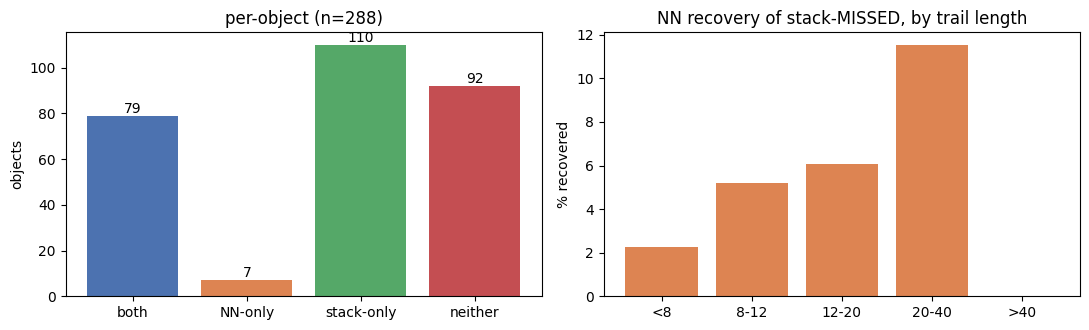

In [5]:
ps = RES / 'per_sighting.csv'
if ps.exists():
    o = pd.read_csv(ps)
    g = o.groupby('ObjID').agg(nn=('nn_detected','any'), st=('stack_detected','any'))
    cats = ['both','NN-only','stack-only','neither']
    vals = [int((g.nn & g.st).sum()), int((g.nn & ~g.st).sum()),
            int((~g.nn & g.st).sum()), int((~g.nn & ~g.st).sum())]
    fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
    ax[0].bar(cats, vals, color=['#4c72b0','#dd8452','#55a868','#c44e52'])
    ax[0].set_title(f'per-object (n={len(g)})'); ax[0].set_ylabel('objects')
    for i, v in enumerate(vals): ax[0].text(i, v, str(v), ha='center', va='bottom')
    miss = o[~o.stack_detected].copy()
    if len(miss):
        miss['Lbin'] = pd.cut(miss.trail_length, [0,8,12,20,40,1e4],
                              labels=['<8','8-12','12-20','20-40','>40'])
        t = miss.groupby('Lbin', observed=True).nn_detected.mean()
        ax[1].bar(t.index.astype(str), 100*t.values, color='#dd8452')
        ax[1].set_title('NN recovery of stack-MISSED, by trail length')
        ax[1].set_ylabel('% recovered')
    plt.tight_layout(); plt.show()
else:
    print('[missing] per_sighting.csv — run §2 first.')

## §3 — FP fact-correction & where the gains are (SNR)

The headline FP counts every NN component; a deployed 2nd stage cross-matches against the stack, so the honest metric is **genuine FP** (not on a stack residual, `frac_real_label_overlap < 0.05`). And the *discovered*-asteroid catalog is bright-biased — a detection-independent matched-filter SNR shows the stack is already ~complete for SNR≥5, so a 2nd stage can only help at SNR≈3–7.

```bash
sbatch ADCNN/scripts/test_real/slurm_fp_pipeline.sh
python -m ADCNN.evaluation.fp_analysis sweep-curve --data DATA_DIFFIM/test_real \
    --results-dir experiments/diffim_runs/test_real/results
```

  WHERE ARE THE 2nd-STAGE GAINS?  (matched-filter SNR of the trail)
stack_rec / nn_rec = recall in that SNR bin; nn_recovers_missed = of
the stack-MISSED in that bin, fraction the NN catches (pure gain).

          n  stack_rec  nn_rec  miss_n  nn_recovers_missed
snrbin                                                    
<3      960      0.133   0.081     832               0.043
3-5     101      0.673   0.515      33               0.242
5-7      89      0.978   0.640       2               0.000
7-10     95      0.979   0.411       2               0.500
10-15   129      0.922   0.217      10               0.000
15-25   181      0.956   0.022       8               0.000
>25     674      0.957   0.004      29               0.000

stack-missed mf_snr: median=0.2 p90=2.8 p99=794.8 max=79183236812.6
stack-missed sightings with mf_snr>15: 38/917 (4.1%)  >25: 30 (3.3%)
=> sensible retrain SNR ceiling ~ the p99 of stack-missed; beyond that the stack already gets it.




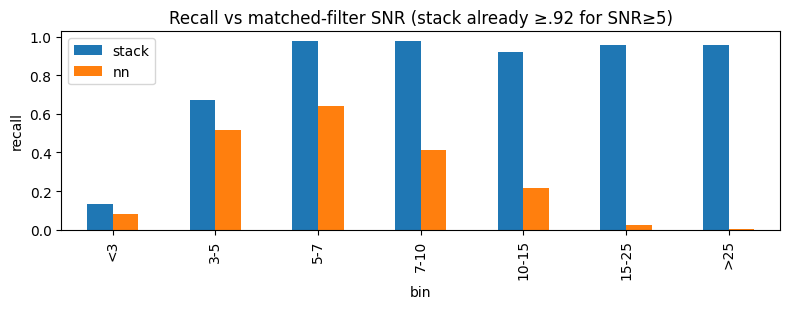

In [6]:
show(RES / 'snr_gain.txt', 'sbatch ADCNN/scripts/test_real/slurm_fp_pipeline.sh')
print()
sg = RES / 'per_sighting_snr.csv'
if sg.exists():
    s = pd.read_csv(sg)
    s['bin'] = pd.cut(s.mf_snr, [-1e9,3,5,7,10,15,25,1e9],
                      labels=['<3','3-5','5-7','7-10','10-15','15-25','>25'])
    t = s.groupby('bin', observed=True).agg(stack=('stack_detected','mean'),
                                            nn=('nn_detected','mean'))
    ax = t.plot.bar(figsize=(8,3.2)); ax.set_ylabel('recall')
    ax.set_title('Recall vs matched-filter SNR (stack already ≥.92 for SNR≥5)')
    plt.tight_layout(); plt.show()

## §4 — Recovery-vs-FP threshold curve

Is there *any* RF operating point where the current pipeline is a usable 2nd stage?

In [7]:
show(RES / 'threshold_sweep.txt',
     'python -m ADCNN.evaluation.fp_analysis sweep-curve --data DATA_DIFFIM/test_real '
     '--results-dir experiments/diffim_runs/test_real/results')

  thr  FP/empty missSight_rec  NEW_obj
--------------------------------------
 0.02     468.0    133/917 (14.5%)   22/99
 0.05     200.9     78/917 ( 8.5%)   14/99
 0.10      79.2     46/917 ( 5.0%)    8/99
 0.15      44.7     27/917 ( 2.9%)    4/99
 0.20      31.4     19/917 ( 2.1%)    3/99
 0.30      18.6     13/917 ( 1.4%)    2/99
 0.40      12.4      7/917 ( 0.8%)    2/99
 0.50       8.3      3/917 ( 0.3%)    0/99
 0.70       2.9      2/917 ( 0.2%)    0/99
 0.90       0.6      0/917 ( 0.0%)    0/99



## §5 — FP cleanup: RF hard-negatives + precision-tilt fine-tune

No redesign. (1) Retrain the V2 RF with real empty-CCD residuals as hard negatives; (2) precision-tilt **fine-tune** v7 (resumes shipped weights, FP-penalising AFTL, 4× neg anchors).

```bash
sbatch ADCNN/scripts/test_real/slurm_finetune.sh     # ~1h GPU, new run v7_ft_hn
sbatch ADCNN/scripts/test_real/slurm_ft_eval.sh      # dump-empty/-syn (ft) + fp-fix
```

`fp_fix.txt` = ORIGINAL vs FINE-TUNED genuine FP/CCD on held-out real empties at matched synthetic recall.

In [8]:
show(RES / 'fp_fix.txt', 'sbatch ADCNN/scripts/test_real/slurm_finetune.sh ; '
     'sbatch ADCNN/scripts/test_real/slurm_ft_eval.sh')

[real-empty] 131494 cand over 150 CCDs -> train 100 CCD/87202 cand | heldout 50 CCD/44292 cand

==== FP/CCD on HELDOUT real empties — CURRENT rf ====
  thr  FP_all/CCD  FP_genuine/CCD
 0.05       207.8           202.7
 0.10        85.3            84.6
 0.20        33.5            33.3
 0.30        20.5            20.3
 0.50         9.8             9.7
 0.70         3.3             3.3
(FP_all = every NN comp; FP_genuine = not on a stack residual the stack already flags, i.e. what a deployed 2nd stage truly adds)

[synthetic] 37976 cand  pos=864 neg=37112  relabel 4s
[combined] 125178 rows (+87202 real-empty neg)
[train] new RF in 13s -> /sdf/data/rubin/user/mrakovci/Projects/Asteroid_detection_CNN/experiments/diffim_runs/pilot_v7/ckpts/rf_postproc_v2_realneg.pkl

==== HELDOUT real-empty FP/CCD : OLD vs NEW rf ====
  thr |  OLD all  OLD gen |  NEW all  NEW gen
 0.05 |    207.8    202.7 |     75.6     75.1
 0.10 |     85.3     84.6 |     42.6     42.4
 0.20 |     33.5     33.3 |     21.9

## §6 — Synthetic-bar gate & promotion

Promote the fine-tuned artifacts **only if** they hold the synthetic objectwise bar (≈840 combined-TP at ≤~10k FP on `test_5sigma`).

```bash
sbatch ADCNN/scripts/test_real/slurm_bar.sh          # bar_shipped.txt vs bar_ft.txt
bash   ADCNN/scripts/test_real/promote.sh            # if ft holds (backs up *.preft.bak)
```

In [9]:
for tag in ('shipped','ft'):
    print('='*60)
    show(RES / f'bar_{tag}.txt', 'sbatch ADCNN/scripts/test_real/slurm_bar.sh')
    print()

=== BAR shipped ===  model=v7_scripted.pt rf=rf_postproc_v2.pkl
       split   thr |  NN_TP   NN_FP  NN_FN |   cTP     cFP   cFN  nObj
 test_5sigma  0.10 |    833    2471    167 |   838    8876   162  1000
 test_5sigma  0.20 |    832    1113    168 |   837    7518   163  1000
 test_5sigma  0.50 |    792     314    208 |   800    6719   200  1000


=== BAR ft ===  model=v7_ft_last_scripted.pt rf=rf_postproc_v2_ft.pkl
       split   thr |  NN_TP   NN_FP  NN_FN |   cTP     cFP   cFN  nObj
 test_5sigma  0.10 |    854    3121    146 |   859    9526   141  1000
 test_5sigma  0.20 |    854    1572    146 |   859    7977   141  1000
 test_5sigma  0.50 |    853     443    147 |   858    6848   142  1000




## Conclusion

* **Leakage:** zero `(visit,detector)` overlap — Train/Test untouched.
* **`test_real` is bright-biased** (discovered asteroids): stack ≈complete for SNR≥5; the addressable 2nd-stage prize is the narrow faint band (SNR≈3–7). Recall value of v7 stands on the *synthetic* sets (`Evaluation.ipynb`).
* **FP cleanup (no redesign):** RF real-hard-negatives + precision-tilt fine-tune **≈halve** genuine FP/CCD on real diffims with synthetic trail-recall preserved/improved; the fine-tuned pipeline also **improves the synthetic bar** (combined-TP up at lower FP at thr 0.5). Promoted as default (`DEFAULT_THR=0.50`); revert via `restore.sh`.

Full pipeline + order: `ADCNN/scripts/test_real/REPRODUCE.md`.